In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('../data/raw/train.csv')
df_test = pd.read_csv('../data/raw/test.csv')

print(df_train.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


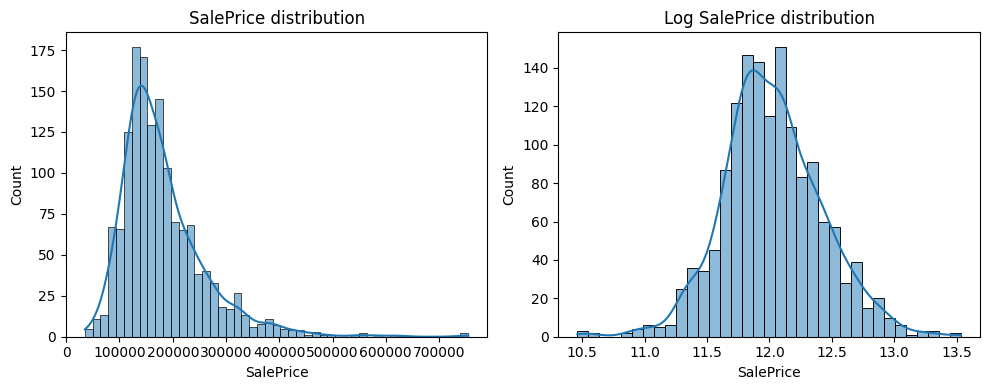

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_train['SalePrice'], kde=True)
plt.title('SalePrice distribution')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_train['SalePrice']), kde=True)
plt.title('Log SalePrice distribution')
plt.tight_layout()
plt.show()

In [7]:
corr = df_train.select_dtypes(include=np.number).corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


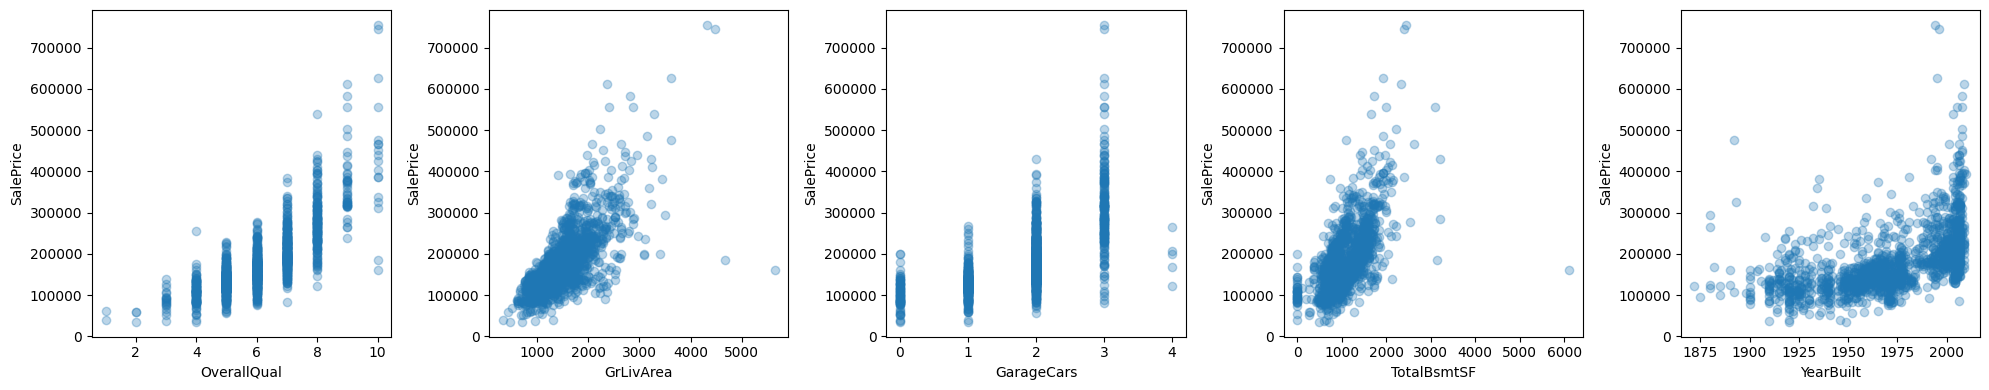

In [8]:
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(top_features):
    axes[i].scatter(df_train[col], df_train['SalePrice'], alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [9]:
df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [10]:
df_train = df_train.drop(df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)].index)
print(df_train.shape)

(1458, 81)


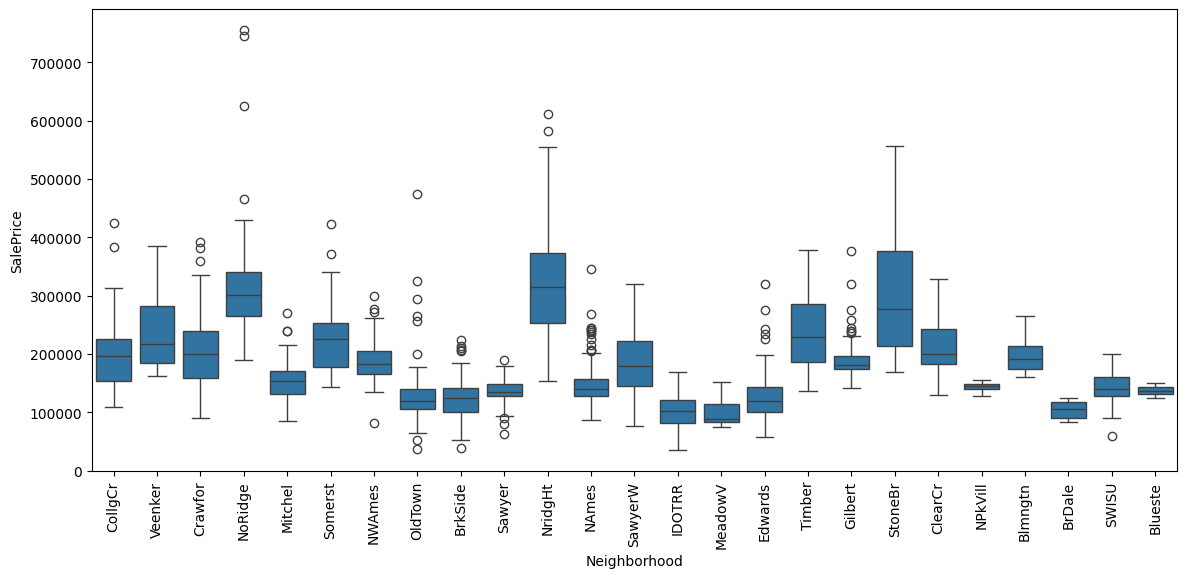

In [11]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_train, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=90)
plt.show()

In [12]:
cat_cols = df_train.select_dtypes(include='object').columns
for col in cat_cols:
    print(col, df_train[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 7
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


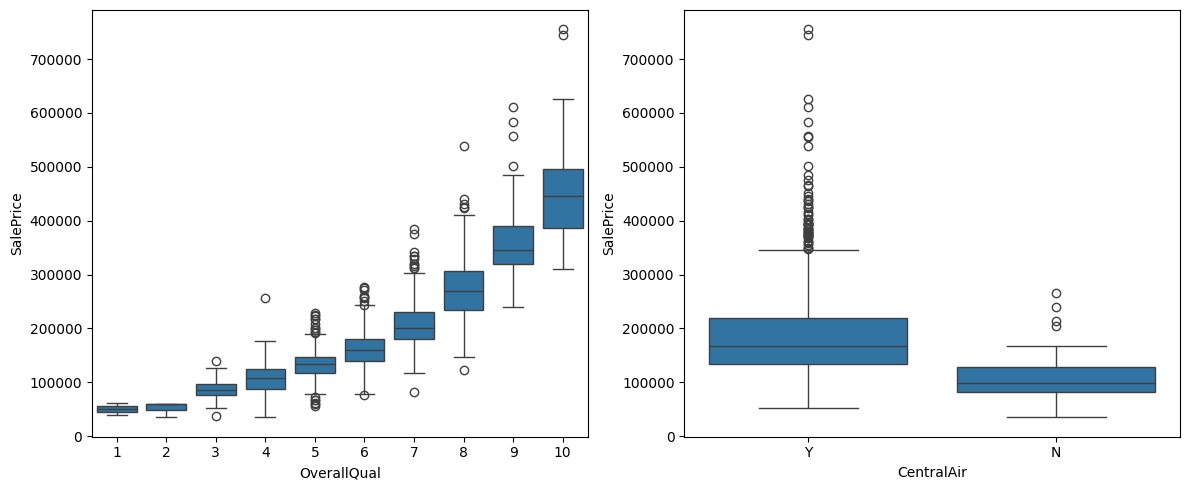

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_train, x='OverallQual', y='SalePrice', ax=axes[0])
sns.boxplot(data=df_train, x='CentralAir', y='SalePrice', ax=axes[1])
plt.tight_layout()
plt.show()

In [14]:
df_train['SalePrice_log'] = np.log1p(df_train['SalePrice'])

train_ids = df_train['Id']
test_ids = df_test['Id']

y = df_train['SalePrice_log']
df_train_features = df_train.drop(['SalePrice', 'SalePrice_log'], axis=1)

all_data = pd.concat([df_train_features, df_test], axis=0, ignore_index=True)
print(all_data.shape)

(2917, 80)


In [15]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

print(all_data[none_cols].isnull().sum())

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
MasVnrType      0
dtype: int64


In [16]:
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

print(all_data[zero_cols].isnull().sum())

GarageYrBlt     0
GarageArea      0
GarageCars      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
MasVnrArea      0
dtype: int64


In [17]:
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

LotFrontage    486
MSZoning         4
Utilities        2
Functional       2
Exterior1st      1
Exterior2nd      1
Electrical       1
KitchenQual      1
SaleType         1
dtype: int64


In [18]:
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
print(all_data['LotFrontage'].isnull().sum())

0


In [19]:
mode_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st',
             'Exterior2nd', 'Electrical', 'KitchenQual', 'SaleType']

for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(all_data.isnull().sum().sum())

0


In [20]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

print(all_data[qual_cols].head())

   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  PoolQC  
0            0           3           3       0  
1            3           3           3       0  
2            3           3           3       0  
3            4           3           3       0  
4            3           3           3       0  


In [21]:
all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)

all_data['GarageFinish'] = all_data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

print(all_data[['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish']].isnull().sum())

BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
GarageFinish    0
dtype: int64


In [22]:
remaining_cat_cols = all_data.select_dtypes(include='object').columns
print(remaining_cat_cols)
print(len(remaining_cat_cols))

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir',
       'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')
29


In [23]:
all_data = pd.get_dummies(all_data, columns=remaining_cat_cols, drop_first=True)
print(all_data.shape)

(2917, 214)


In [24]:
X_train = all_data.iloc[:len(df_train)]
X_test = all_data.iloc[len(df_train):]

print(X_train.shape)
print(X_test.shape)
print(y.shape)

(1458, 214)
(1459, 214)
(1458,)
